# EXERCISE 5

In [1]:
%load_ext sql
%env DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

env: DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db


In [118]:
import matplotlib.pyplot as plt

In [2]:
%%sql

SHOW DATABASES;

4 rows affected.


Database
information_schema
mysql
performance_schema
sys


In [3]:
%%sql

CREATE DATABASE world;
USE world;
SHOW DATABASES;

 * mysql+mysqlconnector://root:***@db
1 rows affected.
0 rows affected.
5 rows affected.


Database
information_schema
mysql
performance_schema
sys
world


In [4]:
import mysql.connector

conn = mysql.connector.connect(user='root', password='root_pwd', database='world', host="db")
cursor = conn.cursor()

with open('../dbs/world.sql', 'r') as f:
    sql = f.read()
    for statement in sql.split(';'):
        if statement.strip():
            cursor.execute(statement)

conn.commit()
cursor.close()
conn.close()

In [5]:
%%sql

SHOW TABLES;

 * mysql+mysqlconnector://root:***@db
3 rows affected.


Tables_in_world
city
country
countrylanguage


In [6]:
%%sql
SELECT *
FROM country;

 * mysql+mysqlconnector://root:***@db
239 rows affected.


Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
ABW,Aruba,North America,Caribbean,193.00,None,103000,78.4,828.00,793.00,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix,129,AW
AFG,Afghanistan,Asia,Southern and Central Asia,652090.00,1919,22720000,45.9,5976.00,None,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar,1,AF
AGO,Angola,Africa,Central Africa,1246700.00,1975,12878000,38.3,6648.00,7984.00,Angola,Republic,José Eduardo dos Santos,56,AO
AIA,Anguilla,North America,Caribbean,96.00,None,8000,76.1,63.20,None,Anguilla,Dependent Territory of the UK,Elisabeth II,62,AI
ALB,Albania,Europe,Southern Europe,28748.00,1912,3401200,71.6,3205.00,2500.00,Shqipëria,Republic,Rexhep Mejdani,34,AL
AND,Andorra,Europe,Southern Europe,468.00,1278,78000,83.5,1630.00,None,Andorra,Parliamentary Coprincipality,,55,AD
ANT,Netherlands Antilles,North America,Caribbean,800.00,None,217000,74.7,1941.00,None,Nederlandse Antillen,Nonmetropolitan Territory of The Netherlands,Beatrix,33,AN
ARE,United Arab Emirates,Asia,Middle East,83600.00,1971,2441000,74.1,37966.00,36846.00,Al-Imarat al-´Arabiya al-Muttahida,Emirate Federation,Zayid bin Sultan al-Nahayan,65,AE
ARG,Argentina,South America,South America,2780400.00,1816,37032000,75.1,340238.00,323310.00,Argentina,Federal Republic,Fernando de la Rúa,69,AR
ARM,Armenia,Asia,Middle East,29800.00,1991,3520000,66.4,1813.00,1627.00,Hajastan,Republic,Robert Kotšarjan,126,AM


## 1) Which country has the largest population?

In [7]:
%%sql

SELECT Name, Population 
FROM country
ORDER BY Population DESC
LIMIT 1;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


Name,Population
China,1277558000


## 2) Get the total number of cities in Canada.

In [8]:
%%sql

SELECT * 
FROM country
WHERE Name = "Canada";

 * mysql+mysqlconnector://root:***@db
1 rows affected.


Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
CAN,Canada,North America,North America,9970610.00,1867,31147000,79.4,598862.00,625626.00,Canada,"Constitutional Monarchy, Federation",Elisabeth II,1822,CA


In [9]:
%%sql

SELECT COUNT(*) AS CitiesInCanada
FROM city
WHERE CountryCode = "CAN";

 * mysql+mysqlconnector://root:***@db
1 rows affected.


CitiesInCanada
49


## 3) Select the country with the most cities.

In [10]:
%%sql

SELECT CountryCode,COUNT(*) AS NumCities
FROM city
GROUP BY CountryCode
ORDER BY NumCities DESC
LIMIT 1;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


CountryCode,NumCities
CHN,363


## 4) List all the languages spoken in the Southeast Asia region.

In [11]:
%%sql

SELECT Region, COUNT(*) AS Countries
FROM country
WHERE Region LIKE "%Asia"
GROUP BY Region;

 * mysql+mysqlconnector://root:***@db
3 rows affected.


Region,Countries
Southern and Central Asia,14
Southeast Asia,11
Eastern Asia,8


In [12]:
%%sql
SELECT DISTINCT countrylanguage.Language
FROM country, countrylanguage
WHERE country.Region = "Southeast Asia"
AND country.Code = countrylanguage.CountryCode
ORDER BY countrylanguage.Language;

 * mysql+mysqlconnector://root:***@db
47 rows affected.


Language
Bali
Banja
Batakki
Bicol
Bugi
Burmese
Cebuano
Chin
Chinese
Dusun


In [57]:
%%sql

# sorting them out based on the number of countries that speak those languages
SELECT DISTINCT countrylanguage.Language, COUNT(*) AS NCountries
FROM country, countrylanguage
WHERE country.Region = "Southeast Asia"
AND country.Code = countrylanguage.CountryCode
GROUP BY countrylanguage.Language
ORDER BY NCountries DESC;

 * mysql+mysqlconnector://root:***@db
47 rows affected.


Language,NCountries
Chinese,6
Malay,5
Thai,3
Khmer,3
English,2
Lao,2
Vietnamese,2
Sunda,2
Tamil,2
Hiligaynon,1


## 5) Identify the 5 most spoken languages by number of countries.

In [72]:
%%sql
SELECT Language, COUNT(*) AS Countries
FROM country, countrylanguage
WHERE country.Code = countrylanguage.CountryCode
GROUP BY Language
ORDER BY Countries DESC
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


Language,Countries
English,60
Arabic,33
Spanish,28
French,25
German,19


## 6) What is the total population of the cities in the Caribbean region?

In [92]:
%%sql
SELECT SUM(city.Population) AS TotalPopulation
FROM country, city
WHERE country.Code = city.CountryCode
AND country.Region = "Caribbean";

 * mysql+mysqlconnector://root:***@db
1 rows affected.


TotalPopulation
11067550


## 7) What Countries have a City named "Kingston"?

In [101]:
%%sql
SELECT country.Name, Region
FROM city, country
WHERE city.Name = "Kingston"
AND country.Code = city.CountryCode;

 * mysql+mysqlconnector://root:***@db
2 rows affected.


Name,Region
Jamaica,Caribbean
Norfolk Island,Australia and New Zealand


## 8) Plot the population density by country, limiting to the 25 with the least density.

In [105]:
%%sql
SELECT Name, Population/SurfaceArea  AS PopulationDensity
FROM country
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


Name,PopulationDensity
Aruba,533.6788
Afghanistan,34.8418
Angola,10.3297
Anguilla,83.3333
Albania,118.3108


 * mysql+mysqlconnector://root:***@db
25 rows affected.


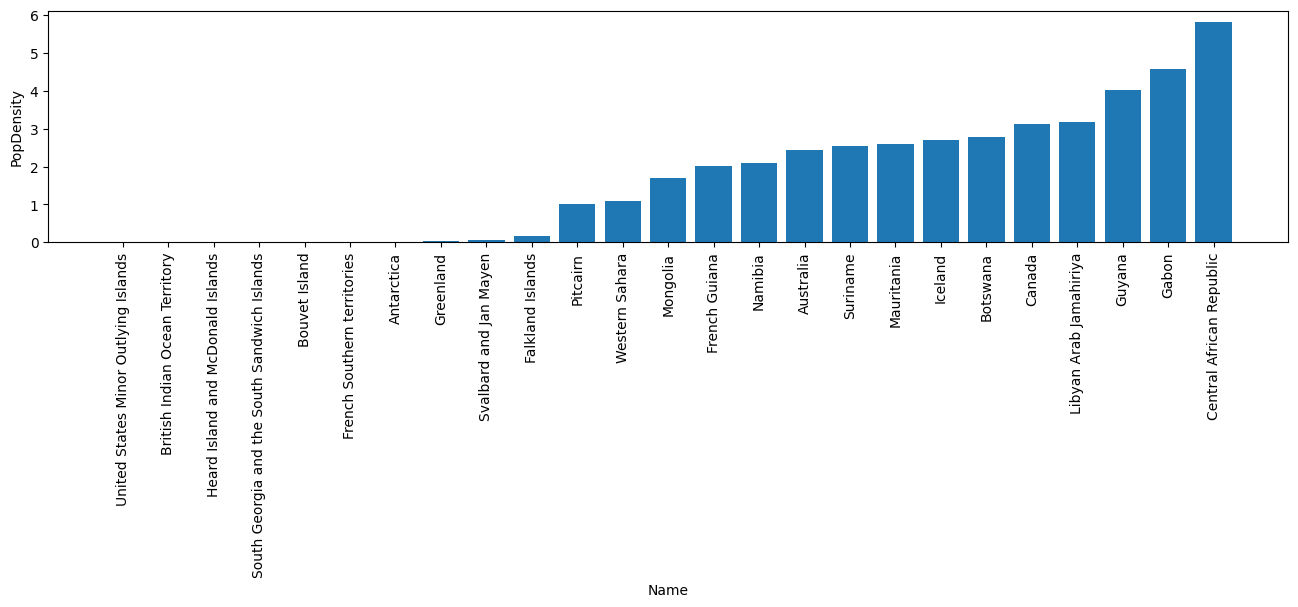

In [134]:
res = %sql SELECT Name, Population/SurfaceArea AS PopDensity FROM country ORDER BY PopDensity LIMIT 25;

plt.figure(figsize=(16,3))
res.bar()
plt.xticks(rotation="vertical");


## 9) Plot the GNP (Gross Nation Product) of all countries that become independent between 1850 and 1910, limiting to the 10 with the highest GNP

 * mysql+mysqlconnector://root:***@db
10 rows affected.


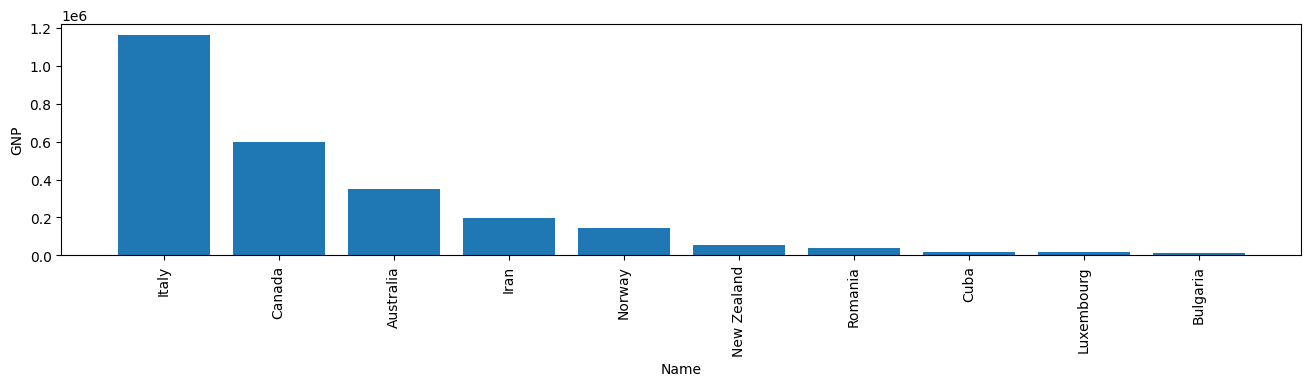

In [153]:
res = %sql SELECT Name, GNP FROM country WHERE IndepYear < 1910 AND IndepYear > 1850 ORDER BY GNP DESC LIMIT 10;
plt.figure(figsize=(16,3))
res.bar()
plt.xticks(rotation="vertical");

## 10) Create a scatter plot of the life expectancy vs the GNP of all countries that have Spanish as their Official language

 * mysql+mysqlconnector://root:***@db
28 rows affected.


Text(0, 0.5, 'Life Expectancy')

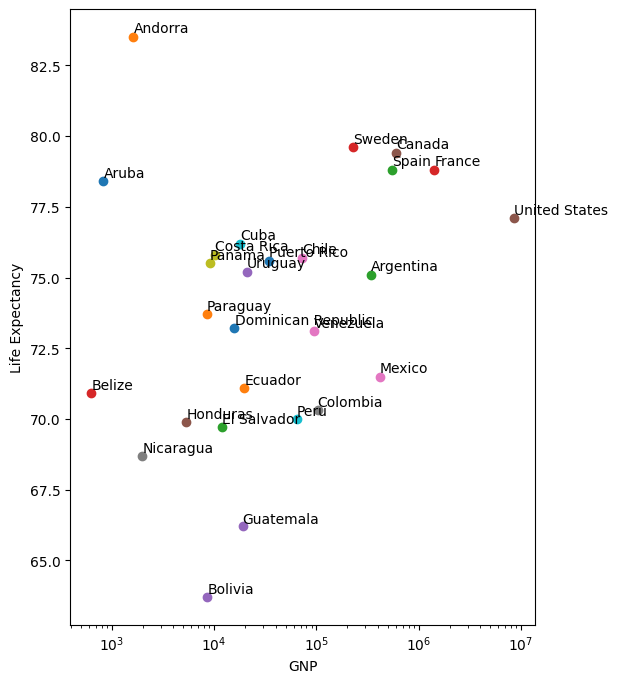

In [181]:
res = %sql \
SELECT Name, GNP, LifeExpectancy FROM country, countrylanguage \
WHERE country.Code = countrylanguage.CountryCode AND countrylanguage.Language = "Spanish";

plt.figure(figsize=(6,8))
for (name, gnp, lifeexp) in res:
    plt.scatter(gnp, lifeexp)
    plt.annotate(name, (float(gnp)*1.002, float(lifeexp)*1.002))
plt.xscale("log")
plt.xlabel("GNP")
plt.ylabel("Life Expectancy")

In [15]:
%%sql
SHOW TABLES;

 * mysql+mysqlconnector://root:***@db
3 rows affected.


Tables_in_world
city
country
countrylanguage
